# Métodos de Treino Baseados em Árvores

Neste capítulo, vamos estudar de forma aprofundada modelos de treinamento baseados em árvores, que são amplamente utilizados em problemas de classificação e regressão. Esses modelos são populares devido à sua simplicidade, não sendo necessário padronizar os dados, e interpretabilidade, permitindo que os usuários compreendam facilmente como as decisões são tomadas.

## Árvores de Decisão

Uma árvore de decisão opera através de uma estrutura hierárquica, na qual cada nó interno representa um teste sobre um atributo de um dado. Os ramos que partem desse nó correspondem aos possíveis resultados do teste, segmentando os dados até que um nó folha, que contém a classificação final, seja alcançado. Veja a figura abaixo para uma representação visual:

![Nomenclatura_Arvore](img/Nomenclatura_Arvore.png)

## Problemas de Classificação

No processo de construção de uma árvore de decisão para classificação é importante ressaltar que a separação dos dados deve envolver apenas duas respostas: “Sim” ou “Não”. Também é preciso definir a ordem das variáveis, como a variável com que se deve começar, qual deve ser a seguinte, e assim por diante. A solução para isso é obtida através do **grau de impureza das variáveis**.

Dizemos que uma variável é **impura** quando ela não consegue separar bem os dados em uma árvore de decisão. Para calcularmos a impureza de uma variável utilizamos o **indíce Gini**, que varia entre 0 (mais puro possível) e 0,5 (mais impuro possível). Primeiramente, calculamos ele para cada nó da variável, e em seguida obtemos o da variável como uma média ponderada. O índice Gini de um nó é obtido por:

$$
Gini(nó) = 1 - p_s^2 - p_n^2
$$

onde $p_s$ é a proporção de exemplos positivos e $p_n$ é a proporção de exemplos negativos no nó.

O índice Gini da variável é dado por

$$
Gini(variável) = gini(nó_1) \cdot \frac{nó_1}{total} + gini(nó_2) \cdot \frac{nó_2}{total} + ... + gini(nó_n) \cdot \frac{nó_n}{total}
$$

A seguir, vamos ver um exemplo prático de como construir uma árvore de decisão para um problema de classificação utilizando o índice Gini utilizando a base statlog_heart que contém dados sobre pacientes que possuem ou não doenças cardíacas.

In [5]:
import pandas as pd

# Definindo os dicionários para conversão de tipos e mapeamento de valores
tipos_converter = {
    'sex': 'object',
    'chest-pain': 'object',
    'heart-disease': 'object',
    'thal' : 'object',
}

mapeamento_sex = {
    0.0: 'feminino',
    1.0: 'masculino'
}

mapeamento_chest_pain = {
    1.0: 'angina típica',
    2.0: 'angina atípica',
    3.0: 'dor não anginosa',
    4.0: 'assintomática'
}

mapeamento_thal = {
    3.0: 'normal',
    6.0: 'defeito fixo',
    7.0: 'defeito reversível'
}

mapeamento_heart_disease = {
    1: 'não',
    2: 'sim'
}

# importando base de dados
base = pd.read_csv("data/statlog_heart.csv")[['sex', 'chest-pain', 'thal', 'heart-disease']]

# alterando o tipo de algumas colunas de acordo com o dicionário
base = base.astype(tipos_converter)

# alterando os valores de acordo com os dicionários
base['sex'] = base['sex'].map(mapeamento_sex)
base['chest-pain'] = base['chest-pain'].map(mapeamento_chest_pain)
base['heart-disease'] = base['heart-disease'].map(mapeamento_heart_disease)
base['thal'] = base['thal'].map(mapeamento_thal)

# filtrando a base para considerar apenas os tipos de dor torácica relevantes
base = base[(base['chest-pain'] == 'angina típica') |
                         (base['chest-pain'] == 'angina atípica')]

base.head()

,sex,chest-pain,thal,heart-disease
2,masculino,angina atípica,defeito reversível,sim
4,feminino,angina atípica,normal,não
13,masculino,angina típica,normal,sim
18,masculino,angina típica,normal,não
19,masculino,angina típica,defeito reversível,não


Nosso objetivo é prever se um indivíduo tem ou não uma doença cardíaca (variável “HeartDisease”), baseado nas outras variáveis. As variáveis explicativas são as seguintes:
- `sex`: Sexo do paciente (0 = feminino, 1 = masculino)
- `chest-pain`: Tipo de dor no peito (1 = angina típica, 2 = angina atípica, 3 = dor não anginosa, 4 = assintomática)
- `thal`: Talassemia (3 = normal, 6 = defeito fixo, 7 = defeito reversível)

Vamos analisar a capacidade de variáveis individuais em prever a presença de doença cardíaca. Para este exemplo, focaremos em três: `sex`, `chest-pain` e `thal`, começando pela variável `sex`.

In [6]:
# Realizando contagem do número de ocorrências de cada sexo
base['sex'].value_counts()

sex
masculino    42
feminino     20
Name: count, dtype: int64

Note que temos 183 pacientes do sexo masculino e 87 do sexo feminino. Como a resposta de um nó da árvore deve ser “Sim” ou “Não”, vamos utilizar a como teste variável “sex=M”.

In [7]:
# Verificando quantos indivíduos possuem doença cardíaca de acordo com o sexo
pd.crosstab(base['sex'], base['heart-disease'])

heart-disease,não,sim
sex,,
feminino,19,1
masculino,31,11


In [8]:
0.38 * (42 / 62) + 0.095 * (20 / 62)

0.2880645161290322

Então a variável “`sex`=M” separa os pacientes da seguinte forma

!["heart_disease_1"](img/heart_disease_1.jpg)

Note que a maioria dos pacientes com doença cardíaca terminaram na folha referente ao sexo masculino, mas a maioria dos que não possuem doença também. Já podemos ter uma ideia que essa variável não é tão boa em separar os dados, mas para averiguarmos essa hipótese vamos calcular o índice Gini dela.

Primeiramente, o índice do nó “Sex = M Sim”:

$$
Gini(sex = M Sim) = 1 - \left(\frac{11}{42}\right)^2 - \left(\frac{31}{42}\right)^2 = 0.38
$$

A seguir, “Sex = M Não”:

$$
Gini(sex = M Não) = 1 - \left(\frac{1}{20}\right)^2 - \left(\frac{19}{20}\right)^2 = 0.095
$$

Por fim, o índice Gini da variável “Sex = M”:

$$
Gini(sex = M) = 0.38 \cdot \frac{42}{62} + 0.095 \cdot \frac{20}{62} = 0.28
$$

Como o índice Gini da variável “`sex` = M” ficou mais próximo de 0,5 do que de 0, podemos constatar que ela é uma variável com baixa pureza. Note que se tivéssemos escolhido a variável “`sex` = F” o índice Gini obtido seria o mesmo, pois “`sex` = F sim” é equivalente a “`sex` = M não” e “`sex` = F não” é equivalente a “`sex` = M sim”. ou seja, as contas seriam as mesmas.

Agora, vamos realizar o mesmo processo para a variável "chest-pain", utilizando somente os casos 'angina atípica' e 'angina típica'.

In [9]:
# Verificando quantos indivíduos possuem doença cardíaca de acordo com o tipo de dor torácica
base.groupby('chest-pain')['heart-disease'].value_counts().sort_index()

chest-pain      heart-disease
angina atípica  não              35
                sim               7
angina típica   não              15
                sim               5
Name: count, dtype: int64

Vamos considerar a variável “ChestPain = Typical”. Ela separa os dados da seguinte forma

!["chest_pain_typical"](img/heart_disease_2.jpg)

Note que quase metade dos pacientes que possuem dor no peito têm doença cardíaca. Dos que não sentem a dor no peito, quase $\frac{1}{4}$ apenas possui a doença.

Índice Gini do nó “ChestPain = Typical Sim”:

$$
Gini(chest-pain = Typical Sim) = 1 - \left(\frac{5}{20}\right)^2 - \left(\frac{15}{20}\right)^2 = 0.38
$$

Índice Gini do nó “ChestPain = Typical Não”:

$$
Gini(chest-pain = Typical Não) = 1 - \left(\frac{7}{42}\right)^2 - \left(\frac{35}{42}\right)^2 = 0.28
$$

Índice Gini da variável “ChestPain = Typical”:

$$
Gini(chest-pain = Typical) = 0.38 \cdot \frac{30}{72} + 0.28 \cdot \frac{42}{72} = 0,32
$$

Note que ela obteve um índice Gini um pouco maior do que a variável “sex = M”. Isso indica que a variável “sex = M” é mais pura do que a variável “ChestPain = Typical”.

Agora, falta apenas obter o índice Gini da variável “thal”. Mas diferentemente das outras 2 ela não possui apenas 2 níveis, e sim 3: “normal”, “fixed” e “reversable”. Nesse caso vamos ter que calcular o índice Gini para todas as combinações possíveis: “thal = normal”, “thal = fixed”, “thal = reversable”, “thal = normal ou fixed”, “thal = normal ou reversable”, “thal = fixed ou reversable”. Porém note que o índice Gini da variável “thal = normal” é equivalente ao da variável “thal = fixed ou reversable”, pois “thal = normal Sim” é o mesmo que “thal = fixed ou reversable Não”. Da mesma forma isso vale para as variáveis “thal = fixed” e “thal = normal ou reversable”, e “thal = reversable” e “thal = normal ou fixed”. Com isso conseguimos economizar algumas contas.

In [10]:
base.groupby(['thal'])['heart-disease'].value_counts().sort_index()

thal                heart-disease
defeito fixo        não               3
                    sim               1
defeito reversível  não               7
                    sim               6
normal              não              40
                    sim               5
Name: count, dtype: int64

Vamos, primeiramente, olhar para a variável “thal = normal”. Ela separa os dados da seguinte forma:

!["thal_normal"](img/heart_disease_3.jpg)

Note que a maioria dos pacientes que possuem doença cardíaca estão no grupo dos que possuem “thal = normal”.

Vamos calcular o índice Gini do nó “thal = normal sim”:

$$
Gini(thal = \text{normal}_{\text{sim}}) = 1 - \left(\frac{40}{45}\right)^2 - \left(\frac{5}{45}\right)^2 = 0.11
$$

Agora vamos calcular o índice Gini do nó “thal = normal não”:

$$
Gini(thal = \text{normal}_{\text{não}}) = 1 - \left(\frac{7}{17}\right)^2 - \left(\frac{10}{17}\right)^2 = 0.49
$$

Então, o índice Gini da variável “thal = normal” é:

$$
Gini(thal = normal) = 0.11 \cdot \frac{45}{62} + 0.49 \cdot \frac{17}{62} = 0.24
$$

Agora vamos olhar para a variável “thal = fixo”. Ela separa os dados da seguinte forma:

!["thal_fixed"](img/heart_disease_4.jpg)

Vamos calcular o índice Gini do nó “thal = fixo sim”:

$$
Gini(thal = \text{fixed}_{\text{sim}}) = 1 - \left(\frac{1}{4}\right)^2 - \left(\frac{3}{4}\right)^2 = 0.38
$$

Agora vamos calcular o índice Gini do nó “thal = fixo não”:

$$
Gini(thal = \text{fixed}_{\text{não}}) = 1 - \left(\frac{11}{58}\right)^2 - \left(\frac{47}{58}\right)^2 = 0.29
$$

Então o índice Gini da variável “thal = fixo” fica da seguinte forma:

$$
Gini(thal = fixed) = 0.38 \cdot \frac{4}{62} + 0.29 \cdot \frac{58}{62} = 0.30
$$

Por último, vamos olhar para a variável “thal = reversível".

!["thal_reversable"](img/heart_disease_5.jpg)

Vamos calcular o índice Gini do nó “thal = reversível Sim”:

$$
Gini(thal = \text{reversable}_{\text{sim}}) = 1 - \left(\frac{6}{13}\right)^2 - \left(\frac{7}{13}\right)^2 = 0.46
$$

Agora vamos calcular o índice Gini do nó “thal = reversível Não”:

$$
Gini(thal = \text{reversable}_{\text{não}}) = 1 - \left(\frac{6}{49}\right)^2 - \left(\frac{43}{49}\right)^2 = 0.29
$$

Então o índice Gini da variável “thal = reversível” fica da seguinte forma:

$$
Gini(thal = reversable) = 0.46 \cdot \frac{13}{62} + 0.29 \cdot \frac{49}{62} = 0.31
$$

Resumindo, os índices de todas as variáveis são:

$$
\begin{table}[h!]
\centering
\caption{Índice Gini para a Variável Thal}
\begin{tabular}{lc}
\toprule
\textbf{Variáveis} & \textbf{Índice Gini} \\
\midrule
Thal = Normal & 0,24 \\
Thal = Fixo & 0,30 \\
Thal = Reversível & 0,31 \\
\bottomrule
\end{tabular}
\end{table}
$$

A variável “thal = reversable” é a que possui o menor índice Gini, portanto ela é a mais pura. Ela ficará no topo da árvore de decisão, ou seja, será o nó raiz.

!["raiz_arvore_final"](img/Raiz_Arvore_Final.png)

O próximo passo é definir as variáveis que ficarão no nó “thal = reversível sim” e “thal = reversível não”. Para isso temos que olhar para a base de dados com os indivíduos de cada grupo.


In [11]:
# grupo de indivíduos "thal = reversível sim"
grupo_reversivel_sim = base[(base['thal'] == 'defeito reversível') & (base['heart-disease'] == 'sim')]

grupo_reversivel_sim.head()

,sex,chest-pain,thal,heart-disease
2,masculino,angina atípica,defeito reversível,sim
59,masculino,angina atípica,defeito reversível,sim
144,masculino,angina atípica,defeito reversível,sim
160,masculino,angina típica,defeito reversível,sim
210,masculino,angina típica,defeito reversível,sim


Agora temos que calcular o índice Gini para todas as variáveis referentes a esse grupo. A que for mais pura entrará no nó “thal = reversível Sim”. Poupando os cálculos, vamos obter que o menor índice Gini é o da variável “chest-pain = típica”.

In [12]:
# grupo de indivíduos "thal = reversível não"
grupo_reversivel_nao = base[(base['thal'] == 'defeito reversível') & (base['heart-disease'] == 'não')]

grupo_reversivel_nao.head()

,sex,chest-pain,thal,heart-disease
19,masculino,angina típica,defeito reversível,não
43,masculino,angina atípica,defeito reversível,não
87,masculino,angina típica,defeito reversível,não
158,masculino,angina típica,defeito reversível,não
192,masculino,angina atípica,defeito reversível,não


Agora calculamos também o índice Gini para todas as variáveis referentes a esse grupo. Após os cálculos necessários veremos que o menor índice Gini é o da variável “chest-pain = atípica".

Dessa forma, podemos dar continuidade a nossa árvore.

!["raiz_arvore_final"](img/Arvore_de_Decisao_Final.png)

Após obtidos esses novos nós, o processo continua se repetindo, obtendo novos nós e/ou folhas para a árvore, até a construção chegar ao fim.

Pergunta: quando o processo de construção de uma árvore chega ao fim? O processo de construção pode terminar por 3 fatores:

   - Quando a pureza do nó é maior do que o de qualquer variável que adicionamos;
   - Quando atingimos folhas 100% puras (índice Gini = 0);
   - Quando o ganho ao aumentar a árvore é muito pequeno.

O ganho ao aumentar a árvore pode ser resumido como um conjunto de atributos presentes na árvore que retornem o maior ganho de informações. Essa questão será melhor abordada posteriormente, juntamente com a questão de como podar as árvores (que está intimamente relacionada ao ganho) no subcapítulo XGBoost.

## Problemas de Regressão

Agora iremos discutir o processo de construção de uma árvore de regressão. Em uma árvore de regressão, diferentemente de uma árvore para classificação, cada folha possui um valor numérico (ao invés de categorias como “Sim” ou “Não”, como no exemplo anterior da base SmallHeart). Vejamos a seguir um exemplo de árvore de decisão para um problema de regressão.

![Arvore_Regressao](img/Ex_Arvore_Reg-01.png)

Esse valor numérico presente nas folhas não é nada menos que a média do valor da variável de interesse a ser prevista para os elementos que satisfazem a condição do nó. Por exemplo, na árvore de regressão acima a primeira folha dá como resultado uma eficácia de 5%: essa foi a média observada da eficácia do medicamento em pacientes com mais de 50 anos de idade. Para a segunda folha, a com eficácia de 20%: esse valor é a média da eficácia do medicamento em um indivíduo com menos de 50 anos de idade e que toma uma dosagem maior do que 29mg foi de 20%. O processo é o mesmo para as outras folhas.

A grande pergunta é qual valor colocar no nó como condição. Para exemplificar como funciona o processo, vamos começar com um exemplo simples:

Ex.: Vamos carregar o banco de dados “SmallAdvertising”. Este banco possui informações sobre as vendas de um produto em 10 mercados diferentes (variável sales), além de orçamentos de publicidade para esse produto em cada um dos mercados para três mídias diferentes: TV, rádio e jornal (variáveis TV, radio e newspaper, respectivamente).

In [13]:
vendas = pd.read_csv("data/advertising.csv")

vendas

,TV,radio,newspaper,sales
0,200.0,2.6,21.2,10.6
1,66.1,5.8,24.2,8.6
2,215.0,24.0,4.0,17.4
3,23.8,35.1,65.9,9.2
4,97.5,7.6,7.2,9.7
5,204.0,32.9,46.0,19.0
6,195.0,47.7,52.9,22.4
7,67.8,36.6,114.0,12.5
8,281.0,39.6,55.8,24.4
9,69.2,20.5,18.3,11.3


Vamos considerar o caso em que queremos construir uma árvore de regressão para prever as vendas baseados apenas na variável TV.

<Axes: xlabel='TV', ylabel='sales'>

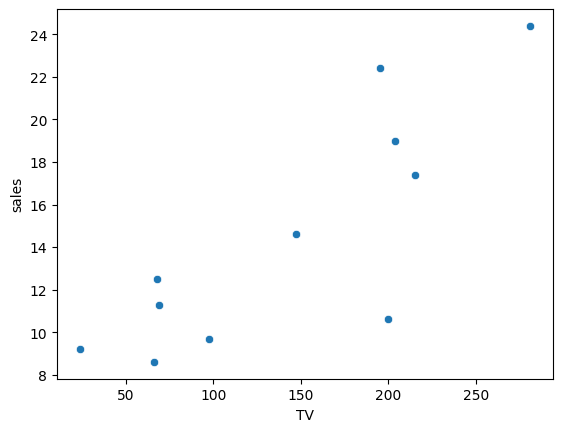

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=vendas, x='TV', y='sales')

Primeiramente é preciso definir qual valor irá entrar como condição no primeiro nó. O algoritmo realiza isso testando todos os possíveis valores de separação para os dados e pega o que minimiza a **soma dos quadrados dos resíduos**. Inicialmente, como o primeiro separador, ele considera a média dos 2 menores valores da Publicidade.

In [15]:
import statistics as stat

ordenados = vendas['TV'].sort_values(ascending=True)

stat.mean(ordenados[0:2])

44.949999999999996

Então 2.4 é o primeiro valor a ser testado para a separação dos dados.

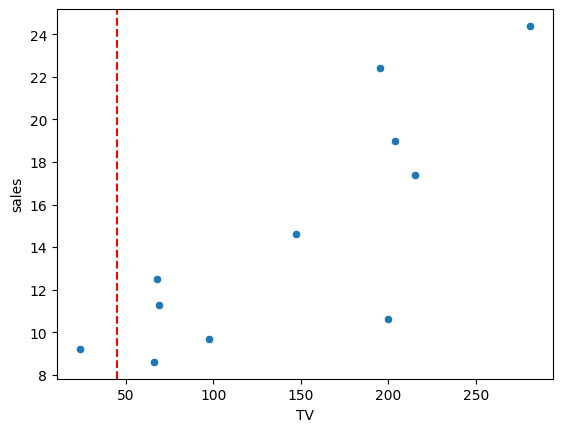

In [16]:
sns.scatterplot(data=vendas, x='TV', y='sales')
plt.axvline(x=44.95, color='red', linestyle='--', label='Média das duas menores vendas')

In [17]:
stat.mean(vendas[vendas['TV'] > 44.95]['sales'])

15.049999999999999

Assim, o primeiro nó será da seguinte forma:

!["ArvReg1-01"](img/ArvReg1-01.png)

Para a resposta “sim”, prevemos que o total de vendas do produto será de 0.7, que é o resultado da média dos valores das vendas para todos os produtos cuja publicidade foi menor do que 2.4, ou seja, o valor do primeiro elemento. Para a resposta “Não”, então a folha seguinte contém o resultado da média dos valores das vendas para todos os produtos cuja publicidade foi maior do que 2.4, o qual é de 147.78.

Note que, fazendo isso, teremos resíduos (diferença do valor original e do valor predito pela árvore) muito grandes. O algoritmo eleva esses resíduos ao quadrado e os soma. Esse valor é a soma dos quadrados dos resíduos considerando o nó “Publicidade para a TV < 44,95?”.

Em seguida ele irá para o próximo separador: a média do segundo e do terceiro menores pontos.

In [18]:
stat.mean(ordenados[1:3])

66.94999999999999

Então 4,75 é o segundo valor a ser testado para a separação dos dados.

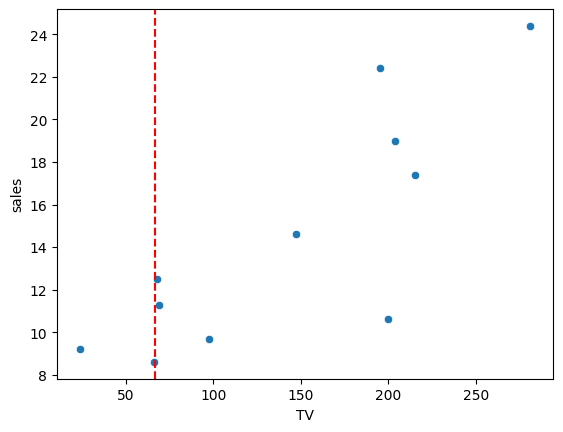

In [19]:
sns.scatterplot(data=vendas, x='TV', y='sales')
plt.axvline(x=66.95, color='red', linestyle='--', label='Média das duas menores vendas')

Então o nó considerado será da forma “Publicidade para a TV < 66.95?”.

!["ArvReg2"](img/ArvReg2.png)

O valor de 2.4 corresponde ao resultado da média dos valores das vendas para todos os produtos cuja publicidade foi menor do que 4.75. O valor de 148.5 é o resultado da média dos valores das vendas para todos os produtos cuja publicidade foi maior do que 4.75. Novamente serão obtidos os resíduos dessa predição e eles serão somados.

Então o algoritmo irá para o próximo separador e irá calcular a soma dos quadrados dos resíduos da predição. Isso ocorre sucessivamente até acabarem todos os separadores possíveis para a árvore. O separador vencedor (aquele que irá para o nó raiz) é aquele com a menor soma dos quadrados dos resíduos.

A construção dos próximos nós se dá pela mesma forma que a do nó raiz. O processo de construção da árvore termina quando:

   - Atingimos um número mínimo de observações em uma folha (usualmente é utilizado 20 observações). Não continuamos a divisão após esse número mínimo pois corremos o risco de criar uma árvore sobreajustada à amostra dada;

   - Quando o ganho ao aumentar a árvore é muito pequeno.

Agora vamos para o caso em que tenhamos mais de uma variável preditiva nos dados. Vamos considerar agora que queremos prever as vendas do produto baseado em seus orçamentos de publicidade para TV, rádio e jornal.

Assim como anteriormente, começamos usando o orçamento para a TV para prever as vendas e pegamos o separador com a menor soma dos quadrados dos resíduos. O melhor separador se torna um candidato para a raiz da árvore. Em seguida, focamos em utilizar o orçamento para o rádio para prever as vendas. Assim como com o orçamento para a TV, tentamos diferentes separadores para a predição e calculamos a soma dos quadrados dos resíduos em cada passo. O melhor separador se torna outro candidato para a raiz. Por último, utilizamos o orçamento para o jornal para prever as vendas, e após tentarmos diferentes separadores pegamos aquele com a menor soma dos quadrados dos resíduos também. Então comparamos a soma dos quadrados dos resíduos de todos os candidatos para a raiz, e o escolhido, novamente, é aquele com a menor soma.

Para os próximos nós o processo de construção também é equivalente ao anterior, exceto que agora nós comparamos a menor soma dos quadrados dos resíduos de cada preditor. E, novamente, quando uma folha atinge um número mínimo de observações, a árvore é finalizada.

## Árvores com o Scikit-learn

Para construir árvores de decisão de forma fácil, podemos utilizar a biblioteca Scikit-learn, que possui implementações prontas para problemas de classificação e regressão. Nesse sentido, vamos ver como construir uma árvore de decisão para dizer se uma universidade é pública ou privada, utilizando a base de dados `College`, que reune informações de 777 universidades e faculdades dos Estados Unidos, coletadas na década de 1990. A primeira coluna geralmente não tem nome (Unnamed: 0) e contém o nome da instituição. As demais são:

- `Private`: Uma variável categórica (fator) que indica se a universidade é particular ('Yes') ou pública ('No').
- `Apps`: Número de inscrições (applications) recebidas pela instituição.
- `Accept`: Número de inscrições aceitas.
- `Enroll`: Número de novos alunos matriculados.
- `Top10perc`: Percentual de novos alunos que estavam entre os 10% melhores de sua turma no ensino médio.
- `Top25perc`: Percentual de novos alunos que estavam entre os 25% melhores de sua turma no ensino médio.
- `F.Undergrad`: Número de alunos de graduação em tempo integral (Full-time).
- `P.Undergrad`: Número de alunos de graduação em tempo parcial (Part-time).
- `Outstate`: Custo da mensalidade para alunos de fora do estado (em dólares). Para faculdades particulares, este valor é geralmente o mesmo para todos.
- `Room.Board`: Custo de moradia e alimentação (em dólares).
- `Books`: Custo estimado com livros (em dólares).
- `Personal`: Custo pessoal estimado para o aluno (lazer, etc., em dólares).
- `PhD`: Percentual do corpo docente que possui doutorado (Ph.D.).
- `Terminal`: Percentual do corpo docente que possui um diploma terminal (o mais alto em sua área, que pode ser um Ph.D., MFA, etc.).
- `S.F.Ratio`: Relação Aluno/Professor (Student/Faculty ratio). Um número menor indica turmas menores e mais professores por aluno.
- `alumni.perc`: Percentual de ex-alunos que doam para a instituição.
- `Grad.Rate`: Taxa de graduação (percentual de alunos que se formam).

Vamos começar importando as bibliotecas necessárias e carregando a base de dados:

In [20]:
# Importando as bibliotecas
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

college = pd.read_csv("data/College.csv").drop(columns=['Unnamed: 0'])

X = college.drop(columns=['Private'])
y = college['Private']

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Vamos treinar o modelo através da função `DecisionTreeClassifier` do Scikit-learn. Essa função permite que especifiquemos o hiperparâmetro `max_depth`, que limita a profundidade da árvore para evitar overfitting. Em seguida, treinamos o modelo com os dados de treinamento e avaliamos sua acurácia nos dados de teste.



In [21]:
# Treinando o modelo
# max_depth é um hiperparâmetro que limita a profundidade da árvore para evitar overfitting
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Fazendo previsões e avaliando o modelo
accuracy = clf.score(X_test, y_test)
print(f"Acurácia do modelo: {accuracy:.2f}")

Acurácia do modelo: 0.88


Por fim, vamos visualizar a árvore de decisão treinada. Podemos utilizar a função `plot_tree` do Scikit-learn para isso:



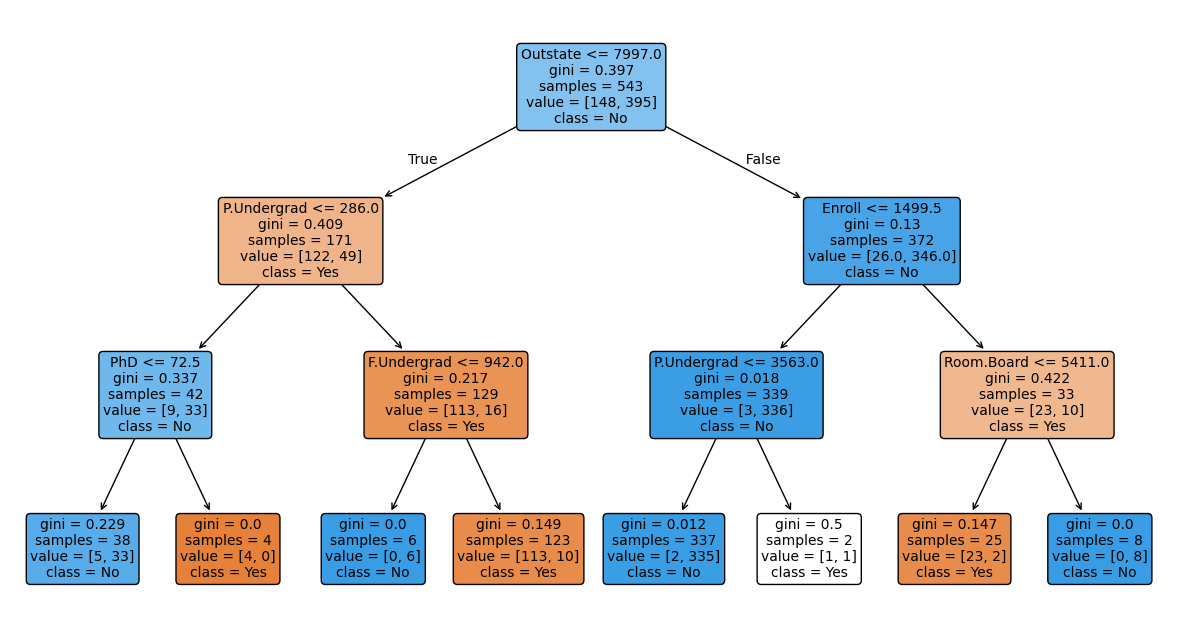

In [22]:
# Visualizando a Árvore de Decisão

# obtendo os nomes das colunas e classes
feature_names = X.columns
class_names = y.unique()

plt.figure(figsize=(15, 8))
plot_tree(clf,
          feature_names=feature_names,  
          class_names=class_names,      
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()

## Florestas Aleatórias

As árvores de decisão possuem uma estrutura de fácil compreensão, o que faz com que elas sejam bastante utilizadas. Mas elas possuem uma limitação, o sobreajuste, sendo assim, não são muito eficientes com novas amostras. Para contornar isso, utilizamos as Florestas Aleatórias (Random Forests), que se utilizam de várias árvores de decisão, combinando a simplicidade das árvores com a flexibilidade de um método sem sobreajuste, o que aumenta a precisão do preditor.

Dessa forma, os passos para construir uma floresta aleatória são:
1. Selecionar aleatoriamente um subconjunto dos dados de treinamento.
2. Sortear aleatoriamente um subconjunto de variáveis para cada árvore.
3. Construir uma árvore de decisão com esse subconjunto e os dados selecionados.
4. Repetir os passos 1 e 2 várias vezes para criar múltiplas árvores de decisão.
5. Combinar as previsões de todas as árvores para obter uma previsão final.

Vamos construir uma floresta aleatória usando a base de dados balloons.

In [23]:
balloons = pd.read_csv("data/balloons.csv")

Com base na cor do balão (`color`), o tamanho dele (`size`), se ele é elástico ou não (`act`) 1 e se quem o está enchendo é uma criança ou um adulto (`age`), queremos predizer se o balão vai encher ou não. Portanto, nossa variável de interesse é `Inflated` e queremos construir um **classificador**.

A primeira coisa que precisamos fazer é criar uma nova amostra do mesmo tamanho da original utilizando bootstrap.

In [24]:
from sklearn.utils import resample

nova_amostra = resample(
    balloons,  # DataFrame original
    replace=True,  # Permite amostragem com reposição
    random_state=42,  # Seed para reprodutibilidade
    n_samples=len(balloons)  # Tamanho da nova amostra igual ao original
)

# Obtendo os índices únicos que foram selecionados para a nova amostra
indices_in_bag = nova_amostra.index.unique()

# Obtendo os índices do DataFrame original que NÃO estão na lista de `indices_in_bag`
oob_indices = balloons.index.difference(indices_in_bag)

# Usando os índices para selecionar as linhas OOB do DataFrame original
out_of_bag = balloons.loc[oob_indices]

Todas as observações que não forem sorteadas vão entrar no “Out-of-Bag”.

Agora, vamos selecionar aleatoriamente um subconjunto de variáveis para a primeira árvore.

In [25]:
import random

random.seed(414)  # Definindo a semente para reprodutibilidade

# Selecionando aleatoriamente um subconjunto de variáveis para a primeira árvore
variaveis = list(balloons.drop(columns=['inflated']).columns)
variaveis_selecionadas = random.sample(variaveis, k=2)

variaveis_selecionadas

['age', 'size']

Vamos calcular o índice Gini para cada variável e escolher a que tiver o menor valor do índice para ser a raiz da árvore. 

In [26]:
pd.crosstab(nova_amostra['size'], nova_amostra['inflated'])

inflated,F,T
size,,
LARGE,4,4
SMALL,3,9


In [27]:
# Calculando o indice de Gini para a variável 'color'
gini_color = (1 - (9/12)**2 - (3/12)**2)*(12/20) + ((1 - 4/8)**2 - (4/8)**2)*(8/20) 

gini_color

0.22499999999999998

In [28]:
pd.crosstab(nova_amostra['age'], nova_amostra['inflated'])

inflated,F,T
age,,
ADULT,2,13
CHILD,5,0


In [29]:
# Calculando o índice de Gini para a variável 'age'
gini_age = (1 - (0/5)**2 - (5/5)**2)*(5/20) + (1 - (13/15)**2 - (2/15)**2)*(15/20)

gini_age

0.17333333333333328

A variável `age` tem um grau de impureza menor, então ela será a raiz da árvore.

!["floresta1"](img/floresta1.jpeg)

Agora das variáveis que ainda não foram usadas, sorteamos mais duas para continuar a árvore.

In [30]:
random.seed(42)

# Selecionando aleatoriamente um subconjunto de variáveis para a segunda árvore
variaveis_2 = list(balloons.drop(columns=['inflated', 'color', 'age']).columns)
variaveis_selecionadas_2 = random.sample(variaveis_2, k=2)

variaveis_selecionadas_2

['size', 'act']

In [31]:
pd.crosstab(nova_amostra['size'], nova_amostra['inflated'])

inflated,F,T
size,,
LARGE,4,4
SMALL,3,9


In [32]:
# Calculando o índice de Gini para a variável 'size'
gini_size = (1 - (4/8)**2 - (4/8)**2)*(8/20) + (1 - (3/12)**2 - (9/12)**2)*(12/20)

gini_size

0.425

In [33]:
pd.crosstab(nova_amostra['act'], nova_amostra['inflated'])

inflated,F,T
act,,
DIP,4,0
STRETCH,3,13


In [34]:
# Calculando o índice de Gini para a variável 'act'
gini_act = (1 - (0/4)**2 - (4/4)**2)*(4/20) + (1 - (3/16)**2 - (13/16)**2)*(16/20)

gini_act

0.24375000000000002

Como a variável `act` tem o menor grau de impureza, ela será o próximo nó.

!["floresta2"](img/floresta2.jpeg)

Assim, temos nossa primeira árvore de decisão.

!["floresta3"](img/floresta3.jpeg)

A floresta aleatória pode ser utilizada tanto em classificadores como em regressores. A diferença é que em regressores, utilizamos árvores de regressão no lugar de árvores de classificação.

Em seguida vamos construir várias árvores da mesma maneira que a anterior. Para nosso exemplo vamos construir apenas 4 árvores, mas em geral vamos fazer bem mais que isso.

Temos então nossas 4 árvores construidas.

!["floresta4"](img/floresta4.jpeg)

!["floresta5"](img/floresta5.jpeg)

Para classificar uma nova amostra, devemos passar ela por todas as árvores construidas e rotular a amostra pela categoria resultada mais vezes.

O método de usar bootstrap para criar novas amostras e votos para a tomada de decisão é chamado de `Bagging` (Bootstrap+aggregate).

As observações de cada amostra que não entraram na construção de cada árvore estão contidas `Out of Bag`. Essas observações servirão para avaliar nosso preditor.

In [33]:
out_of_bag

,color,size,act,age,inflated
4,YELLOW,SMALL,DIP,CHILD,F
8,YELLOW,LARGE,DIP,ADULT,F
9,YELLOW,LARGE,DIP,CHILD,F
12,PURPLE,SMALL,STRETCH,CHILD,F
13,PURPLE,SMALL,DIP,ADULT,F
15,PURPLE,LARGE,STRETCH,ADULT,T
17,PURPLE,LARGE,STRETCH,CHILD,F


Para avaliar, é preciso passar cada uma das observações do Out of Bag por todas as árvores e a predição será feita por votos também. Ao fazer isso, observamos uma precisão de (TROCAR BASE E AVALIAR).

A proporção de amostras do Out-of-bag que foram incorretamente classificadas é chamada `Out-of-bag-error`

Agora que sabemos avaliar o modelo, podemos comparar florestas aleatórias construídas com 2 variáveis com as construídas com 3 e outras diferentes configurações. Tipicamente, começamos usando o quadrado do número de variáveis da base e tentamos algumas quantidades abaixo e acima.

### Florestas Aleatórias com o Scikit-learn

Agora, vamos ver como construir uma floresta aleatória utilizando o Scikit-learn. Para isso, vamos usar a base de dados `iris`, que contém informações sobre flores do gênero Iris. A base possui 150 amostras de flores, com 4 variáveis preditivas: `sepal length`, `sepal width`, `petal length` e `petal width`. A variável alvo é a espécie da flor, que pode ser `setosa`, `versicolor` ou `virginica`. Primeiro, vamos importar as bibliotecas necessárias e carregar a base de dados:

In [34]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# Removendo linhas com valores ausentes
balloons = balloons.dropna()

# A coluna 'inflated' também é convertida para o tipo 'category'
balloons['inflated'] = balloons['inflated'].astype('category')

# Separando a variável alvo (y) das preditoras (X)
X = balloons.drop('inflated', axis=1)
y = balloons['inflated']

# Convertendo as variáveis categóricas em numéricas
X = pd.get_dummies(X)

# Dividindo os dados em 70% para treino e 30% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Construindo a floresta aleatória com 20 árvores
modelo = RandomForestClassifier(n_estimators=20, random_state=2025)

# Treinando o modelo
modelo.fit(X_train, y_train)
previsoes = modelo.predict(X_test)

In [35]:
from sklearn.metrics import classification_report, accuracy_score

# Imprime a acurácia geral
acc = accuracy_score(y_test, previsoes)
print(f"Acurácia do Modelo: {acc:.2f}\n") # Exibe a acurácia com 2 casas decimais

# Imprime o relatório completo
print("Relatório de Classificação:")
print(classification_report(y_test, previsoes))

Acurácia do Modelo: 1.00

Relatório de Classificação:
              precision    recall  f1-score   support

           F       1.00      1.00      1.00         2
           T       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



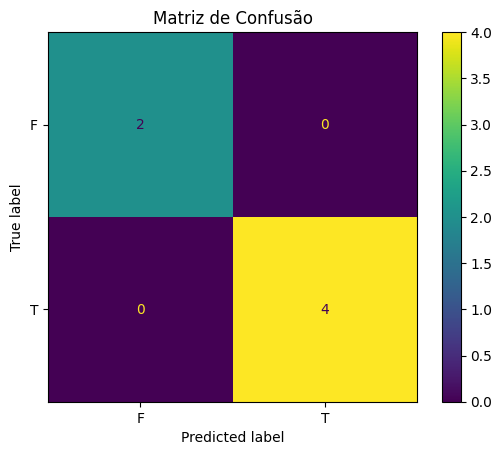

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Gera a matriz de confusão
cm = confusion_matrix(y_test, previsoes, labels=modelo.classes_)

# Plota a matriz de confusão de forma gráfica
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
disp.plot()
plt.title("Matriz de Confusão")
plt.show()

E se fosse usada apenas uma árvore de decisão? Vamos comparar a acurácia de uma árvore de decisão com a de uma floresta aleatória. Para isso, vamos utilizar o classificador `DecisionTreeClassifier` do Scikit-learn para criar uma árvore de decisão.

In [37]:
from sklearn.tree import DecisionTreeClassifier

# Construindo a árvore de decisão
modelo_arvore = DecisionTreeClassifier(random_state=2025)

# Treinando o modelo
modelo_arvore.fit(X_train, y_train)
previsoes_arvore = modelo_arvore.predict(X_test)

In [38]:
# Imprime a acurácia geral
acc = accuracy_score(y_test, previsoes_arvore)
print(f"Acurácia do Modelo: {acc:.2f}\n") # Exibe a acurácia com 2 casas decimais

# Imprime o relatório completo
print("Relatório de Classificação:")
print(classification_report(y_test, previsoes_arvore))

Acurácia do Modelo: 1.00

Relatório de Classificação:
              precision    recall  f1-score   support

           F       1.00      1.00      1.00         2
           T       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



### AdaBoost

O método de treino AdaBoost se baseia na construção de uma floresta aleatória. Entretanto, na floresta construída por esse método as árvores possuem apenas um nó e duas folhas. Essas árvores são chamadas de tocos.

!["Floresta_AdaBoost-01"](img/Floresta_AdaBoost-01.png)

Em geral, tocos não são muito bons em fazer classificações precisas, ou seja, eles são classificadores fracos. No entanto, o método AdaBoost os combina de forma a criar um bom aprendiz. Ele faz isso utilizando diferenciais na classificação e na construção das árvores que a floresta aleatória comum não utiliza:

 - Floresta Aleatória: cada árvore de decisão tem um peso igual na classificação final das amostras. Além disso, cada árvore é construída independentemente das outras.
 - AdaBoost: alguns tocos têm mais peso na classificação final do que outros, e a ordem de construção dos tocos importam. Em outras palavras, os erros que o primeito toco comete influenciam em como o segundo toco é construído, os erros que o segundo toco comete influenciam em como o terceiro toco é construído, e assim sucessivamente.

Vamos ver os detalhes práticos de como funciona o AdaBoost utilizando o banco de dados golf. Este banco possui informações sobre condições climáticas e se o indivíduo jogou golf no dia. A ideia é tentar prever se o indivíduo vai jogar golf baseado nas outras variáveis.

In [39]:
golf = pd.read_csv("data/golf.csv").drop(columns=['Unnamed: 0'])

golf.head()

,Outlook,Humidity,Wind,Play
0,Sunny,High,Weak,No
1,Sunny,High,Strong,No
2,Overcast,High,Weak,Yes
3,Rain,High,Weak,Yes
4,Rain,Normal,Weak,Yes


Primeiramente construímos um toco para cada uma das variáveis e calculamos seus respectivos índices Gini. Vamos começar com a variável Outlook.

In [40]:
golf.groupby('Outlook')['Play'].value_counts().sort_index()

Outlook   Play
Overcast  Yes     4
Rain      No      2
          Yes     3
Sunny     No      3
          Yes     2
Name: count, dtype: int64

Então temos que “Outlook = Overcast” separa os dados da seguinte forma:

!["AB_Overcast"](img/AB_Overcast.png)

**Gini(Outlook = Overcast)** = $ \frac{4}{14} \cdot \left[1 - \left(\frac{4}{4}\right)^2 - \left(\frac{0}{4}\right)^2\right] + \frac{10}{14} \cdot \left[1 - \left(\frac{5}{10}\right)^2 - \left(\frac{5}{10}\right)^2 \right] = 0.357 $

Agora vamos para a Outlook Rain:

!["AB_Rain"](img/AB_Rain.png)

**Gini(Outlook = Rain)** = $ \frac{5}{14} \cdot \left[1 - \left(\frac{3}{5}\right)^2 - \left(\frac{2}{5}\right)^2\right] + \frac{9}{14} \cdot \left[1 - \left(\frac{6}{9}\right)^2 - \left(\frac{3}{9}\right)^2\right] = 0.457 $

e para Otlook Sunny:

!["AB_Sunny"](img/AB_Sunny.png)

**Gini(Outlook = Sunny)** = $ \frac{5}{14} \cdot \left[1 - \left(\frac{2}{5}\right)^2 - \left(\frac{3}{5}\right)^2\right] + \frac{9}{14} \cdot \left[1 - \left(\frac{7}{9}\right)^2 - \left(\frac{2}{9}\right)^2\right] = 0.393 $

Para a variável Humidity temos:

In [41]:
(4/14) * (1 - (4/4)**2 - (0/4)**2) + (10/14) * (1 - (5/10)**2 - (5/10)**2)

0.35714285714285715

In [42]:
golf.groupby('Humidity')['Play'].value_counts().sort_index()

Humidity  Play
High      No      4
          Yes     3
Normal    No      1
          Yes     6
Name: count, dtype: int64

Temos que “Humidity = High” separa os dados da seguinte forma:

!["AB_High"](img/AB_High.png)

**Gini(Humidity = High)** = $ \frac{7}{14} \cdot \left[1 - \left(\frac{3}{7}\right)^2 - \left(\frac{4}{7}\right)^2\right] + \frac{7}{14} \cdot \left[1 - \left(\frac{6}{7}\right)^2 - \left(\frac{1}{7}\right)^2\right] = 0.367 $

Por fim, para a variável Wind:

In [43]:
golf.groupby('Wind')['Play'].value_counts().sort_index()

Wind    Play
Strong  No      3
        Yes     3
Weak    No      2
        Yes     6
Name: count, dtype: int64

!["AB_Wind"](img/AB_Wind.png)

**Gini(Wind = Strong)** = $ \frac{6}{14} \cdot \left[1 - \left(\frac{3}{6}\right)^2 - \left(\frac{3}{6}\right)^2\right] + \frac{8}{14} \cdot \left[1 - \left(\frac{6}{8}\right)^2 - \left(\frac{2}{8}\right)^2\right] = 0.429 $

Logo, os índices Gini de todas as variáveis são:

$$
\begin{table}[h!]
\centering
\caption{Índice Gini para as Variáveis do Banco de Dados Golf}
\begin{tabular}{lc}
\toprule
\textbf{Variáveis} & \textbf{Índice Gini} \\
\midrule
Outlook = Overcast & 0.357 \\
Outlook = Rain & 0.457 \\
Outlook = Sunny & 0.394 \\
Humidity = High & 0.367 \\
Wind = Strong & 0.429 \\
\bottomrule
\end{tabular}
\end{table}
$$

Selecionamos a variável com o menor índice Gini para ser o primeiro toco da floresta. Nesse caso, o menor índice Gini é o da variável “Outlook = Overcast”.

![AB_toco](img/AB_toco.png)

Agora precisamos calcular o peso desse toco na classificação final. Para isso, vamos calcular seu erro total.

O erro total de um toco é calculado pelo número de amostras classificadas erradas dividido pelo total de amostras.

![AB_toco2](img/AB_toco2.png)

Para esse toco houve 5 amostras classificadas erradas em um total de 14. Logo,

$$
Erro Total = \frac{5}{14}
$$

Dessa forma podemos calcular o Amount of Say do toco, que será seu peso na classificação final.

$$
\text{Amount of Say} = \frac{1}{2} \cdot \log\left(\frac{1 - \frac{5}{14}}{\frac{5}{14}}\right) = 0.29 
$$



Agora vamos construir o próximo toco. Para isso damos um peso maior para as amostras que foram classificadas erroneamente no toco anterior. Essas amostras foram as seguintes:

In [44]:
golf[(golf['Outlook'] != 'Overcast') & (golf['Play'] != 'No')]

,Outlook,Humidity,Wind,Play
3,Rain,High,Weak,Yes
4,Rain,Normal,Weak,Yes
8,Sunny,Normal,Weak,Yes
9,Rain,Normal,Weak,Yes
10,Sunny,Normal,Strong,Yes


Então, para rebalancearmos os pesos das amostras classificadas de forma certa e errada, utilizamos as seguintes fórmulas:

$$
\text{Peso de Amostras Erradas} = \text{Erro Total} \cdot e^{\text{Amount of Say}} = \frac{5}{14} \cdot e^{0.29} = 0.477

\text{Peso de Amostras Certas} = \text{Erro Total} \cdot e^{-\text{Amount of Say}} = \frac{5}{14} \cdot e^{-0.29} = 0.267
$$

Então temos os pesos para as amostras:

![Tabela Adaboost](img/Tabela_Adaboost.png)

A soma dos pesos das amostras deve ser 1, mas isso não ocorre: note que a soma resulta em 4,788. Dessa forma, precisamos reescalar os pesos. Faremos isso dividindo cada um deles por 4,788.
Feito isso, temos uma nova tabela de pesos:

![Tabela Adaboost Reescalada](img/tabela_adaboost2.png)

Definidos os pesos, em seguida realizamos uma reamostragem via bootstrap (uma amostragem da própria amostra, com reposição) do mesmo tamanho da base de dados original. A probabilidade de um elemento da amostra ser sorteado é o peso dele.


In [45]:
import numpy as np

amostra = np.arange(1, 15)

pesos = np.repeat(
    a=[0.056, 0.099, 0.056, 0.099, 0.056, 0.057],  # Elementos a serem repetidos
    repeats=[3, 2, 3, 3, 2, 1]                  # Número de vezes que cada elemento é repetido
)

np.random.seed(2025)

resultado_bootstrap = np.random.choice(
    a=amostra,
    size=14,
    replace=True,  # Amostragem com reposição
    p=pesos        # probabilidade de seleção dos elementos
)

print("Amostra original:", amostra)
print("Pesos calculados:", pesos)
print("Resultado do Bootstrap:", resultado_bootstrap)

Amostra original: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Pesos calculados: [0.056 0.056 0.056 0.099 0.099 0.056 0.056 0.056 0.099 0.099 0.099 0.056
 0.056 0.057]
Resultado do Bootstrap: [ 3 13 13  7  6  4 10  8 14 11  7 11  1 11]


Então temos uma nova amostra formada pelos elementos sorteados na reamostragem:

!["ada_tabela_final"](img/ada_tabela_final.png)

Agora, com essa nova amostra, fixamos pesos uniformes para os elementos e repetimos o processo de criação para o próximo toco. Em seguida verificamos os elementos que foram classificados de forma errada, aumentamos seus pesos no banco de dados e repetimos o processo de bootstrap, construindo, assim, o próximo toco. O processo se repete até que a floresta de tocos esteja concluída.

Finalizada a floresta, realizamos a classificação final dos elementos somando os pesos dos tocos para cada classificação e selecionando o maior deles. Por exemplo, em uma floresta com 10 árvores onde 5 delas classificam a amostra na categoria de interesse como “positivo” e 5 delas classificam essa mesma amostra como “negativo”, se a soma dos pesos das que classificaram a amostra como “positivo” for 2,7 e a das que classificaram a amostra como “negativo” for 0,84, a amostra será classificada como “positivo”.

### AdaBoost com o Scikit-learn

A seguir, vamos ver como implementar o AdaBoost utilizando o Scikit-learn. Para isso, vamos usar a base de dados `spam`. Inicialmente, vamos separar a amostra em dados de treino e teste. 

In [46]:
from sklearn.model_selection import train_test_split

spam = pd.read_csv("data/spam.csv")

# Separando a amostra em dados de treino e teste
X = spam.drop(columns=['type'])
y = spam['type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025)

Antes de realizarmos o adaboost precisamos definir a profundidade máxima que as árvores da floresta terão. Faremos isso através do comando rpart.control(). Como o objetivo é construir uma floresta de tocos, as árvores terão todas profundidade 1.

In [47]:
from sklearn.ensemble import AdaBoostClassifier

# Criando o classificador AdaBoost
# Por padrão, o estimador base é um DecisionTreeClassifier(max_depth=1)
adaboost_clf = AdaBoostClassifier(n_estimators=100, # Número de estimadores (árvores) a serem usados 
                                   random_state=2025)

# Treinando o modelo
adaboost_clf.fit(X_train, y_train)

# Fazendo previsões no conjunto de teste
y_pred = adaboost_clf.predict(X_test)

# Avaliando a acurácia do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo AdaBoost: {accuracy:.4f}")

Acurácia do modelo AdaBoost: 0.9428


Para visualizarmos qualquer árvore da floresta utilizamos o comando rpart.plot().

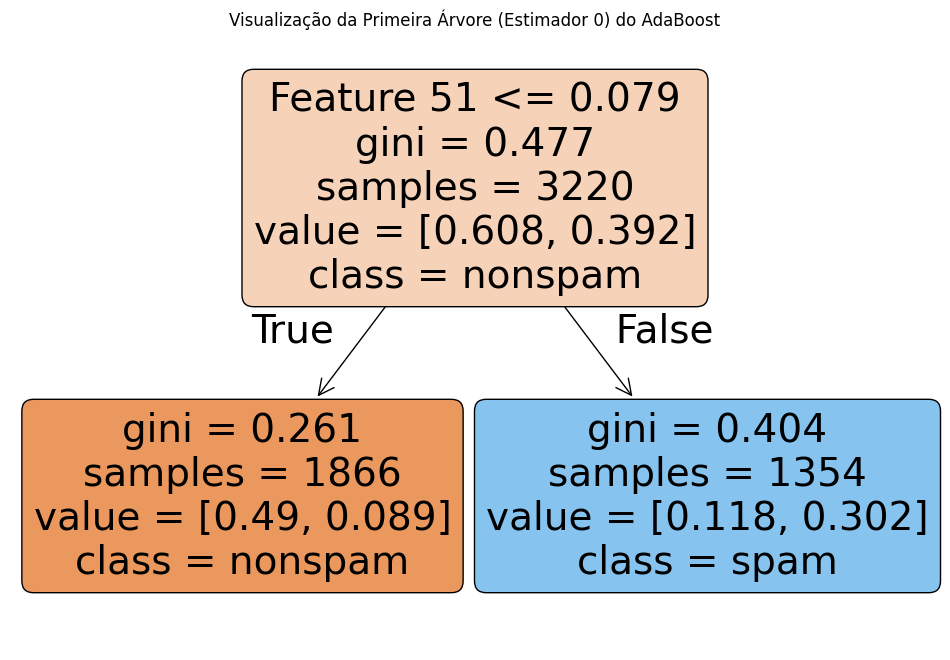

In [48]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Nomes genéricos para as features e classes para uma melhor visualização
feature_names = [f'Feature {i}' for i in range(X.shape[1])]
class_names = [str(c) for c in adaboost_clf.classes_]

# Visualizando a PRIMEIRA árvore (índice 0)
# Esta é a primeira árvore simples que o AdaBoost treinou nos dados originais.
primeira_arvore = adaboost_clf.estimators_[0]

plt.figure(figsize=(12, 8))
plot_tree(primeira_arvore,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True)
plt.title("Visualização da Primeira Árvore (Estimador 0) do AdaBoost")
plt.show()

Por último, vamos aplicar o modelo na amostra teste e em seguida avaliar o modelo através da matriz de confusão.

Text(0.5, 1.0, 'Matriz de Confusão do Modelo AdaBoost')

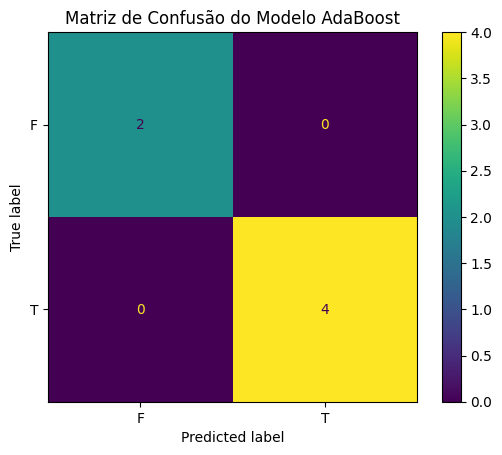

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_ada = confusion_matrix(y_test, y_pred, labels=adaboost_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
disp.plot()
plt.title("Matriz de Confusão do Modelo AdaBoost")

## Gradiente Boosting
O Gradiente Boosting é um método de aprendizado de máquina que combina várias árvores de decisão para criar um modelo preditivo mais robusto. Ele é uma extensão do AdaBoost, mas utiliza uma abordagem diferente para combinar as árvores. Em vez de ajustar os erros de cada árvore, o Gradiente Boosting ajusta os resíduos do modelo anterior, criando uma nova árvore que corrige os erros do modelo anterior.

### Em Regressão

De acordo com Jerome Friedman, o criador do Gradiente Boosting, evidências empíricas mostram que dar pequenos passos ou ir gradativamente na direção correta resulta em melhores predições na amostra teste, ou seja, menor variância.

Para entendermos como funciona o Gradiente Boosting, considere a seguinte base de dados.

In [50]:
##   Altura      Cor Sexo Peso
## 1    1.6     Azul    M   88
## 2    1.6    Verde    F   76
## 3    1.5     Azul    F   56
## 4    1.8 Vermelho    M   75
## 5    1.5    Verde    M   77
## 6    1.4     Azul    F   57

A primeira coisa a fazer é definir um número máximo de folhas de cada árvore. Para nosso exemplo, vamos definir 4 folhas, mas em geral, é definido uma quantidade de 8 a 32 folhas. Feito isso, tiramos uma média dos pesos dos indivíduos e essa será nossa primeira árvore, uma árvore só com a raiz.

![Gradiente Boosting](img/tocoGB.png)

Agora, calculamos o Pseudo-Resíduo, o erro de previsão de cada indivíduo, da forma **Pseudo-Resíduo** = **Valor Real** - **Valor Previsto** para cada observacão. Então, por exemplo, o Pseudo-Resíduo do primeiro indivíduo é 88 - 71.5 = 16.5.

In [51]:
##   Altura      Cor Sexo Peso Ps..Res..1
## 1    1.6     Azul    M   88       16.5
## 2    1.6    Verde    F   76        4.5
## 3    1.5     Azul    F   56      -15.5
## 4    1.8 Vermelho    M   75        3.5
## 5    1.5    Verde    M   77        5.5
## 6    1.4     Azul    F   57      -14.5

O termo pseudo-resíduo é baseado em Regressão Linear, onde o resíduo é a diferença entre os valores observados e estimados. O termo “pseudo” serve para lembrar que estamos fazendo Gradiente Boosting e não Regressão Linear.

O próximo passo é, utilizando as variáveis explicativas (Altura, Cor e Sexo), construir uma árvore de decisão respeitando o máximo de folhas definido anteriormente. Mas ela deve predizer o pseudo-resíduo e não o Peso.

![Árvore de Decisão Pseudo-Resíduo](img/GB1.png)

Note que temos mais observações do que folhas, sendo assim, podemos ter mais que um resultado em cada uma. Nesse caso, substituímos os valores pela média das folhas.

![Árvore de Decisão Pseudo-Resíduo](img/GB2.png)

Agora somamos o resultado das duas árvores para classificar na primeira observação, por exemplo, a predição seria $71,5  + 16,5 = 88$. Acertamos exatamente o valor real. Isso é bom? Não. Já vimos como não é bom ter um modelo muito ajustado. Temos pouco viés, mas provavelmente alta variância.

O Gradiente Boosting lida com esse problema usando uma taxa de aprendizado para reescalar a contribuição da nova árvore. A taxa de aprendizado é um número entre 0 e 1 e deve ser multiplicado ao valor da segunda árvore em diante. Para esse exemplo, vamos adotar uma taxa de 0.1, assim a predição da primeira observação seria $71,5 + (0,1 \cdot 16,5) = 73$. A predição não ficou tão boa, mas é um pouco melhor do que o resultado de apenas uma árvore.

Feito isso, recalculamos os valores do pseudo-resíduo.

In [52]:
##   Altura      Cor Sexo Peso Ps..Res..1 Ps..Res..2
## 1    1.6     Azul    M   88       16.5      14.85
## 2    1.6    Verde    F   76        4.5       4.05
## 3    1.5     Azul    F   56      -15.5     -14.00
## 4    1.8 Vermelho    M   75        3.5       3.05
## 5    1.5    Verde    M   77        5.5       5.05
## 6    1.4     Azul    F   57      -14.5     -13.00

Repare que o valor do segundo pseudo-resíduo diminuiu em módulo em relação ao primeiro, ou seja, nos aproximamos mais do valor correto do que da primeira vez.

Agora, utilizando novamente as variáveis explicativas, construímos outra árvore agora para predizer o segundo pseudo-resíduo.

![Árvore de Decisão Pseudo-Resíduo](img/GB3.png)

Note que a estrutura da segunda árvore construída ficou semelhante a primeira. Isso não acontece sempre, mas pode acontecer.

Agora, a classificação da primeira observação ficaria $71,5 + (0,1 \cdot 16,5) + (0,1 \cdot 14,85) = 74,635$ um pouco mais perto do verdadeiro valor. Repetimos esse procedimento quantas vezes se queira ou até não ter redução significante dos valores do pseudo-resíduo. Dessa forma temos uma sequência de árvores que caminham em direção ao valor correto em passos pequenos.

É importante notar que todas as árvores devem possuir a mesma taxa de aprendizado.

#### Construindo um Regressor com o Scikit-learn

Para nosso exemplo, vamos utilizar a base de dados Wage, ela contém informações sobre os salários de um grupo de trabalhadores da região do Médio Atlântico dos Estados Unidos, coletadas entre 2003 e 2009. Para isso, vamos precisar limpar os dados removendo variáveis de variância zero.

In [53]:
import numpy as np # Importar numpy
from sklearn.feature_selection import VarianceThreshold

wage = pd.read_csv("data/wage.csv").drop(columns=['Unnamed: 0'])

# Selecionar apenas as colunas que são numéricas
wage_numeric = wage.select_dtypes(include=np.number)

# Verificando variáveis de variância zero
selector = VarianceThreshold(threshold=0.2) 
selector.fit_transform(wage_numeric)
colunas_numericas_excluir = wage_numeric.columns[~selector.get_support()]

colunas_numericas_excluir

Index(['logwage'], dtype='object')

In [54]:
# Removendo as colunas de variância zero 
wage.drop(columns=colunas_numericas_excluir, inplace=True)
wage.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,75.043154


Agora, criamos variáveis dummie, pois a função que aplica o gradient booting no scikit-learn não lida com dados categóricos, e dividimos os dados em treino e teste. 

In [55]:
# 2. Separar as variáveis independentes (features, X) e a variável dependente (alvo, y)
X = wage.drop('wage', axis=1)
y = wage['wage']

# A função get_dummies identifica e converte automaticamente as colunas de texto.
# drop_first=True remove a primeira categoria de cada feature para evitar redundância.
X_encoded = pd.get_dummies(X, drop_first=True)

# Dividir os dados em conjuntos de treino e teste (usando os dados já codificados)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=2025)

Agora vamos aplicar o gradiente boosting com a função **GradientBoostingRegressor**. Ela possui os seguintes parâmetros:
- `n_estimators`: número de árvores a serem construídas. O padrão é 100
- `learning_rate`: taxa de aprendizado, que deve ser um número entre 0 e 1. O padrão é 0.1
- `max_depth`: profundidade máxima de cada árvore. O padrão é 3.
- `loss`: função de perda a ser minimizada. O padrão é `squared_error`, que é o erro quadrático médio.
- `random_state`: semente para o gerador de números aleatórios, que garante a reprodutibilidade dos resultados. O padrão é `None`.
- `n_iter_no_change`: número máximo de iterações sem melhoria na função de perda. O padrão é `None`, o que significa que não há limite.
- `validation_fraction`: fração dos dados de treinamento a serem usados para validação. O padrão é 0.1, ou seja, 10% dos dados de treinamento serão usados para validação.
- `tol`: tolerância para a melhoria da função de perda. O padrão é 0.0001, ou seja, a função de perda deve melhorar em pelo menos 0.0001 para continuar o treinamento.

Como pode-se observar nos parâmetros, o modelo treinado vai escolher o número de árvores a serem construídas automaticamente, de forma que vamos obter o resultado possível com o menor número delas. Dessa forma, o parâmetro `n_estimators` serve apenas para definir um limite máximo de árvores a serem construídas.

In [56]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from numpy import sqrt

gbr = GradientBoostingRegressor(
    loss='squared_error',   # Equivalente a distribution="gaussian"
    n_estimators=300,       # Número de árvores
    max_depth=20,           # Profundidade máxima de cada árvore
    random_state=42,
    n_iter_no_change=10,        # Para após 10 iterações sem melhora
    validation_fraction=0.1,    # Usa 10% dos dados de treino como validação
    tol=1e-4
)

#Treinando o modelo
gbr.fit(X_train, y_train)

# Fazendo previsões
y_pred = gbr.predict(X_test)

# Avaliando o modelo
# R-quadrado (R-squared)
r2 = r2_score(y_test, y_pred)

# Erro Absoluto Médio (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Raiz do Erro Quadrático Médio (RMSE)
# Primeiro, calculamos o MSE (Mean Squared Error)
mse = mean_squared_error(y_test, y_pred)
# Depois, tiramos a raiz quadrada
rmse = sqrt(mse)

print(f"RMSE      RSquared      MAE")
print(f"{rmse:.2f}     {r2:.2f}         {mae:.2f}")

RMSE      RSquared      MAE
40.87     0.05         28.55


### Em Classificação

Considere a seguinte base de dados

In [57]:
#   Gosta de Pipoca Idade Cor Favorita Troll 2
#   <chr>           <dbl> <chr>          <chr>    
# 1 Sim                12 Azul           Ama      
# 2 Sim                87 Verde          Ama      
# 3 Nao                44 Azul           Odeia    
# 4 Sim                19 Vermelho       Odeia    
# 5 Nao                32 Verde          Ama      
# 6 Nao                14 Azul           Ama

Queremos predizer se uma pessoa ama o filme Troll 2 baseado em seu gosto por pipoca, idade e cor favorita. Assim como em regressão, começamos o método de Gradiente Boosting usando uma árvore raiz que represente nossa predição inicial para cada observação. Em regressão usamos a média das observações, em classificação vamos usar o log(chances). Olhando na base de dados, podemos dizer que as chances de alguém amar Troll 2 é $\text{chances} = \frac{\text{quantidade de indivíduos que amaram}}{\text{quantidade de indivíduos que odiaram}} = \frac{4}{2}$, e portanto, o log(chances) é $\log\left(\frac{4}{2}\right) = 0.6932$. e é isso que colocaremos na folha inicial.

!["Toco GBC"](img/tocoGBC.png)

O jeito mais fácil de usar o log(chances) para classificar é convertendo em probabilidade, e fazemos isso usando a seguinte função:

$$
\text{Probabilidade} = \frac{e^{log(chances)}}{1+e^{log(chances)}}
$$

Sendo assim, a Probabilidade de alguém amar $ \text{Troll} 2 = \frac{e^{log(\frac{4}{2})}}{1+e^{log{4}{2}}} = \frac{2}{3} = 0,6667$

!["Toco GBC2"](img/tocoGBC2.png)

É importante notar que o log(chances) e a probabilidade só ficaram iguais por causa da aproximação.

Vamos criar o seguinte classificador:

   - Probabilidade acima de 0,5: classificamos que ama Troll 2;
   - Probabilidade menor ou igual a 0,5: classificamos que odeia Troll 2.

Como a probabilidade ficou maior que 0,5 classificamos todos no treino como indivíduos que amam Troll 2.

Embora 0,5 seja um limite usual para tomada de decisão baseada em probabilidade, poderiamos tranquilamente usar um valor diferente.

Mas a classificação não ficou muito boa já que 2 indivíduos foram classificados erroneamente. Podemos mensurar quão ruim foi a predição calculando o pseudo-resíduo = observado - predito. Para essa conta, perceba que se um indivíduo ama Troll 2, então a probabilidade dele amar Troll 2 é 1. Semelhantemente, se ele odeia, a probabilidade dele amar é 0. Assim, calculamos os pseudo-resíduos.

In [58]:
#   Gosta de Pipoca Idade Cor Favorita Troll 2 Ps. Res. 1
#   <chr>           <dbl> <chr>        <chr>       <dbl>
# 1 Sim                12 Azul         Ama         0.3
# 2 Sim                87 Verde        Ama         0.3
# 3 Nao                44 Azul         Odeia       -0.7
# 4 Sim                19 Vermelho     Odeia       -0.7
# 5 Nao                32 Verde        Ama         0.3
# 6 Nao                14 Azul         Ama         0.3

Agora construímos uma árvore utilizando as variáveis explicativas para predizer o pseudo-resíduo. Assim como o Gradiente Boosting para regressão, temos que definir um número máximo de folhas em cada árvore. Aqui vamos limitar a 3 folhas, mas na prática geralmente é um número entre 8 e 32.

!["Toco GB3"](img/tocoGBC3.png)

Em regressão, os valores das folhas representavam os resíduos. Mas em classificação isso é mais complexo. Isso porque a predição está em log(chances) e as folhas são provenientes de probabilidade. Portanto não podemos apenas somá-las para uma nova predição sem alguma transformação. A transformação mais comum por folha é:

$$
\frac{\sum \text{residuos}}{\sum[\text{probabilidade anterior x (1-probabilidade anterior)}]}
$$

Assim, da esquerda para direita, para primeira folha temos:

$$
\begin{align*}
\frac{\sum \text{resíduos}}{\sum[\text{probabilidade anterior} \times (1 - \text{probabilidade anterior})]} = \frac{-0.7}{0.7 \times (0.3)} = -0.3333, \text{para a segunda} \\ \\

\frac{\sum \text{resíduos}}{\sum[\text{probabilidade anterior} \times (1 - \text{probabilidade anterior})]} = \frac{0.3 - 0.7}{0.7 \times (1 - 0.7) + 0.7 \times (1 - 0.7)} = -0.9524, \text{e para a última} \\ \\

\frac{\sum \text{resíduos}}{\sum[\text{probabilidade anterior} \times (1 - \text{probabilidade anterior})]} = \frac{0.3 + 0.3 + 0.3}{0.7 \times (1 - 0.7) + 0.7 \times (1 - 0.7) + 0.7 \times (1 - 0.7)} = 1.4286
\end{align*}
$$

Por enquanto, a probabilidade anterior é a mesma para todos, mas a partir da próxima árvore isso muda.

!["Toco GBC"](img/tocoGBC4.png)

Agora que todas as folhas foram alteradas, podemos somar os resultados escalados pela taxa de aprendizado. Nesse exemplo, vamos usar uma taxa alta, 0.8. Mas geralmente se usa 0.1. E então calculamos o novo $log(\text{chances}) = 0.7 = (0.8 \cdot 1.4) = 1.82$ e então convertemos em probabilidade $\frac{e^{1,82}}{1+e{1,82}} = 0.8606$. Então, note que fizemos progresso, já que o indivíduo em questão ama Troll 2. Antes ele foi classificado corretamente mas com probabilidade 0.7, agora ele foi classificado corretamente mas com probabilidade 0.9.

In [59]:
#   Gosta de Pipoca Idade Cor Favorita Troll 2 Ps. Res. 1
#   <chr>           <dbl> <chr>        <chr>       <dbl>
# 1 Sim                12 Azul         Ama         0.9
# 2 Sim                87 Verde        Ama         0.5
# 3 Nao                44 Azul         Odeia       0.5
# 4 Sim                19 Vermelho     Odeia       0.1
# 5 Nao                32 Verde        Ama         0.9
# 6 Nao                14 Azul         Ama         0.9

Pode ser que a previsão fique pior, como no caso do segundo indivíduo. E essa é a razão de construírmos várias árvores e não só uma.

Calculamos os novos pseudo-resíduos que agora serão diferentes para cada observação.

In [60]:
#   Gosta de Pipoca Idade Cor Favorita Troll 2 Ps. Res. 1
#   <chr>           <dbl> <chr>        <chr>       <dbl>
# 1 Sim                12 Azul         Ama         0.1
# 2 Sim                87 Verde        Ama         0.5
# 3 Nao                44 Azul         Odeia      -0.5
# 4 Sim                19 Vermelho     Odeia      -0.1
# 5 Nao                32 Verde        Ama         0.1
# 6 Nao                14 Azul         Ama         0.1

Construímos uma segunda árvore agora para prever os novos pseudo-resíduos e fazemos a transformação para log(chances) para cada folha.

!["Toco GBC"](img/tocoGBC5.png)

Combinamos com as árvores anteriores para obter um valor de saída e transformamos em Probabilidade para classificar. Por exemplo, a primeira observação ficaria:

$$
log(\text{chances}) = 0.7 + (0.8 \cdot 1.4) + (0.8 \cdot 0.6) = 2.3
$$

e então, convertendo em probabilidade:

$$
\frac{e^{1,82}}{1+e^{1,82}} = 0,9089
$$

Dessa forma, continuamos construíndo quantas árvores forem necessárias.

#### Construindo um Classificador com o Scikit-Learn

O gradiente boosting para classificação no scikit-learn é semelhante ao para regressão, mas com algumas diferenças. A função utilizada é a `GradientBoostingClassifier`, que possui basicamente os mesmos parâmetros que a função para regressão, mas com algumas diferenças na forma como os resíduos são calculados e nas transformações aplicadas às folhas. Vamos utilizar a base de dados vehicle, que contém informações sobre veículos e se eles são de passageiros ou comerciais. A variável alvo é `Class`, que indica se o veículo é de passageiros (`van`) ou comercial (`bus`).

In [61]:
from sklearn.ensemble import GradientBoostingClassifier

vehicle = pd.read_csv("data/vehicle.csv")

# Separando a variável alvo (y) das preditoras (X)
X = vehicle.drop(columns=['Class'])
y = vehicle['Class']

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025)

# Treinando o modelo
gbc = GradientBoostingClassifier(
    n_estimators=100,      # Número de árvores
    max_depth=8,           # Profundidade máxima de cada árvore
    n_iter_no_change=10,   # Para após 10 iterações sem melhora
    validation_fraction=0.1,  # Usa 10% dos dados de treino como
    random_state=100       
)

gbc.fit(X_train, y_train)

# Fazendo previsões
predicao = gbc.predict(X_test)

# Exibindo as 6 primeiras previsões (equivalente ao head())
print(predicao[:6])

['bus' 'van' 'saab' 'opel' 'opel' 'van']


Vamos avaliar o modelo utilizando a matriz de confusão e a acurácia.

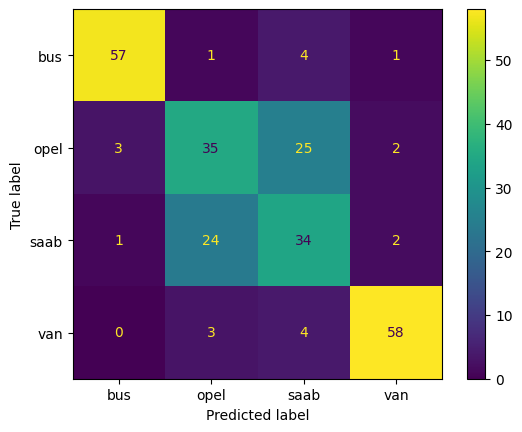

In [62]:
cm_gbc = confusion_matrix(y_test, predicao, labels=gbc.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gbc, display_labels=gbc.classes_)
disp.plot()

In [63]:
# acurácia do modelo
accuracy = gbc.score(X_test, y_test)

print(f"Acurácia do modelo: {accuracy:.2f}")

Acurácia do modelo: 0.72


Note que o modelo obteve uma precisão razoável de 72%

## XGBoost (Extreme Gradient Boost)

O XGBoost é uma implementação otimizada do Gradiente Boosting, que utiliza técnicas avançadas de otimização para melhorar a velocidade e a eficiência do treinamento. Dessa forma, ele consegue lidar melhor com grandes volumes de dados e é mais eficiente em termos de memória. 

### Em Regressão

Apesar do XGBoost ser usado para lidar com bases grandes, vamos usar uma base de dados bem pequena só para entendermos melhor como ele funciona. Para isso considere a seguinte situação: queremos predizer o peso de um indivíduo em função de sua altura.

O primeiro passo é fazer uma predição inicial, que pode ser qualquer uma. O default é usar 0,5, mas como estamos falando de peso, vamos utilizar a predição inicial “Peso = 70”.

!["xgboost1"](img/xgb1.png)

Agora precisamos calcular os resíduos (diferença entre o valor real e o valor predito) que vão nos mostrar quão boa é essa predição.

In [64]:
pa = pd.read_csv("data/peso-altura.csv", sep=';')

pa["residuos"] = pa["Peso"] - 70

Assim como no Gradiente Boosting, o próximo passo é construir uma árvore para predizer os resíduos. Mas o XGBoost utiliza uma árvore de regressão diferente que vamos chamar de árvore XGB. Existem muitas formas de construir uma árvore XGB. Vamos aprender a mais comum. A árvore XGB inicia com uma folha que leva todos os resíduos.

!["xgb2"](img/xgb2.png)

Em seguida, calculamos um índice de qualidade ou Índice de Similaridade.

$$
\text{Índice de Similaridade} = \frac{\sum \text{resíduos}^2}{\text{número de observações} + \lambda}
$$

Onde $\lambda$ (Lambda) é um parâmetro de regularização, o que significa que tem o objetivo de reduzir a sensibilidade das observações individuais, ou seja, reduzir o sobreajuste. Por enquanto, vamos considerar $\lambda = 0$ porque esse é o valor default. Sendo assim, o Índice de similaridade da raiz é $\frac{(18+6-14+5-10)^2}{5+0} = \frac{5^2}{5} = 5$

!["xgb3"](img/xgb3.png)

Agora vamos ver se conseguimos melhorar esse índice dividindo os resíduos, ou seja, criando uma ramificação. Vamos começar dividindo a variável Altura na média entre os dois menores valores, que são 1.4 e 1.5, e calculando o Indice para as novas folhas.

Observe que nas folhas não estarão as alturas e sim os resíduos correspondentes a altura especificada.

!["xgb4"](img/xgb4.png)

Agora, precisamos calcular o ganho dessa ramificação para ver o quanto ela foi efetiva. O ganho é calculado da seguinte forma:

$$
\text{ganho} = \text{IS-folha da esquerda} + \text{IS-folha da direita} - \text{IS-raiz}
$$

Assim, o ganho da ramificação $\text{Altura} < 1,45$ é $100 + 56,25 - 5 = 151,25$. Vamos fazer esse calculo em todas as ramificações possiveis, Isto é, se temos 5 observações com diferentes alturas, vamos ter 4 ramificações possiveis: Altura<1.45, Altura<1.55, Altura<1.65 e Altura<1.75.

!["xgb5"](img/xgb5.png)

Podemos ver que o ganho de usar a ramificação ‘Altura<1.55’ é maior, portanto é essa que vamos usar. Agora vamos ramificar as folhas da mesma maneira e escolher as que tiverem melhor ganho.

Nesse exemplo, vamos limitar a profundidade da árvore XGB em 2. Mas o default é permitir até 6 níveis de profundidade.

Nossa árvore XGB final ficou:

!["xgb6"](img/xgb6.png)

Agora, vamos podar nossa árvore. Fazemos isso porque pode ser que algum nó tenha o ganho muito baixo e por isso não vale a pena estar na árvore. Para decidir se vamos tirar algum nó e, se sim, qual, vamos escolher um valor que será chamado de $\gamma$(gamma). Em seguida, calculamos a diferença entre o ganho associado ao nó e $\gamma$, se essa diferença for negativa, então removemos o nó.

$\gamma$ especifica o ganho mínimo necessario para fazer uma divisão. Seu default é 0. Quanto maior, mais conservador é o modelo.

Mesmo quando $\gamma = 0$ isso não previne podas.

Vamos escolher $\gamma = 10$. Começando sempre dos nós mais profundos para a raiz, vamos avaliar a diferença entre o ganho e $\gamma$. No nó mais a direita temos que o ganho é 32.7, portanto a diferença é $32.7 - 10 = 22.7$, que é positiva, portanto não removemos o nó. No nó à esquerda, a diferença fica $8 - 10 = -2$, e , como o resultado é negativo, removemos o nó. Assim, estamos dizendo que o ganho do nó à esquerda não é bom o suficiente pra justificar essa ramificação. Como o nó à direita permaneceu na árvore, não faz sentido calcular essa diferença para o nó raiz.

Mesmo se o valor da diferença der negativo nos nós de cima, se não removermos o de baixo, o de cima não é removido.

Com isso, nossa árvore XGB ficou:

!["xgb7"](img/xgb7.png)

Note que se tivéssemos escolhido um $\gamma$ muito alto, por exemplo $\gamma = 570$, toda árvore seria podada. É preciso cuidado.

Agora vamos voltar ao inicio e reconstruir a árvore agora usando $\lambda = 1$ (Lembra do ? aquele da fórmula do índicador de similaridade!). Para facilitar a vizualização, vamos omitir os cálculos. A nova árvore XGB ficou:

!["xgb8"](img/xgb8.png)

Podemos notar que quando $\lambda > 0$, o índice de similaridade é menor. O que significa que se mantivermos o mesmo , a poda será mais extrema. Por outro lado, deixar $\lambda > 0$ ajuda a previnir sobreajustes.

Agora que temos árvore final, vamos calcular os valores de saída das folhas.

$$
\text{valores de saída} = \frac{\sum \text{resíduos}}{\text{número de observações} + \lambda}
$$

Repare que essa fórmula é bem parecida com a do índice de similaridade, mas a soma dos resíduos não está ao quadrado.

Repare que, como $\lambda = 0$, o valor de saida é uma média aritmética simples entre os resíduos. Mas note que se $\lambda > 0$ e a folha tiver apenas uma observação, isso reduzira a sensibilidade dessa observação individual evitando sobreajuste.

!["xgb9"](img/xgb9.png)

Assim a primeira árvore está completa e, como em Gradient Boosting, fazemos novas predições começando com a predição inicial e somando com o resultado da árvore XGB escalada pela taxa de aprendizado.

O XGBoost chama a taxa de aprendizado de $\eta$ (eta) e seu valor default é 0.3, que é o que vamos usar.

!["xgb10"](img/xgb10.png)

Por exemplo, se a gente pegasse a primeira observação (indivíduo com altura=1.7), seu peso predito seria $\text{predicao inicial} + \eta \cdot \text{valor de saída da árvore XGB} = 70 + 0,312 = 73,6$ que é mais perto do  seu peso real (que era 88) do que a predição anterior (que era 70). Assim, com as novas predições, os novos resíduos ficaram:

In [65]:
nova_pred = (73.6, 73.6, 66.4, 71.5, 66.4)

pa["residuos2"] = pa["Peso"] - nova_pred

pa

,Altura,Peso,residuos,residuos2
0,1.7,88,18,14.4
1,1.6,76,6,2.4
2,1.5,56,-14,-10.4
3,1.8,75,5,3.5
4,1.4,60,-10,-6.4


Perceba que o novo resíduo é melhor que o anterior (seu valor absoluto é mais próximo de 0). Ou seja, estamos dando pequenos passos na direção correta.

Agora construímos outra árvore XGB da mesma forma, mas para predizer os novos resíduos, Dessa forma obteremos previsões com resíduos menores. E continuamos construíndo árvores XGB até que os resíduos sejam bem pequenos ou até atingir o número de árvores desejado.

### Construindo um Regressor com o Scikit-learn

Vamos usar a base de dados winequality-red. O objetivo dessa base é prever a qualidade do vinho baseado em suas outras variáveis. Mas nós vamos tentar prever o nível alcoólico do vinho.

In [66]:
wine = pd.read_csv("data/winequality-red.csv")

wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Como sempre, vamos dividir a base em amostra de treino e amostra de teste.

In [67]:
X = wine.drop(columns=['quality'], axis=1)
y = wine['quality']

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025)

Agora, vamos importar a função `XGBRegressor` do pacote `xgboost` e criar o modelo. A função `XGBRegressor` possui os seguintes parâmetros:

- `n_estimators`: número de árvores a serem construídas. O padrão é 100.
- `learning_rate`: taxa de aprendizado, que deve ser um número entre 0 e 1. O padrão é 0.3.
- `max_depth`: profundidade máxima de cada árvore. O padrão é 6.
- `min_child_weight`: peso mínimo de cada folha. O padrão é 1.
- `subsample`: fração dos dados de treinamento a serem usados para cada árvore. O padrão é 1, ou seja, todos os dados serão usados.
- `colsample_bytree`: fração das colunas a serem usadas para cada árvore. O padrão é 1, ou seja, todas as colunas serão usadas.

entre outros parâmetros.

In [68]:
import xgboost as xgb

# Criando o modelo XGBRegressor
xgb_regressor = xgb.XGBRegressor(
    n_estimators=300,  # Número de árvores
    learning_rate=0.3,  # Taxa de aprendizado
    random_state=2025   # Semente para reprodutibilidade
)

# Treinando o modelo
xgb_regressor.fit(X_train, y_train)

# Fazendo previsões
y_pred = xgb_regressor.predict(X_test)

# Avaliando o desempenho do modelo
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}, R-squared: {r2:.2f}, MAE: {mean_absolute_error(y_test, y_pred):.2f}")

RMSE: 0.61, R-squared: 0.38, MAE: 0.40


Considerando a escala em que os dados se encontram, o valor do **RMSE** foi um pouco grande e o $R^2$ baixo. Em contrapartida podemos considerar o valor do **MAE** como sendo razoável para o modelo.

### Em Classificação

Para entendermos como o XGBoost funciona para problemas de classificação, vamos utilizar a base de dados **Small College**. O objetivo é prever se a universidade é pública ou privada baseado nos pedidos para ingresso.

O primeiro passo é fazer uma predição inicial. Essa predição pode ser qualquer valor, como por exemplo a probabilidade de observar universidades públicas no conjunto de dados. Por padrão, essa predição é de 0,5.

!["predição inicial"](img/pred_inicial.png)

Feita a predição inicial, agora vamos calcular os resíduos e verificar quão boa é essa predição.

In [69]:
sc = pd.read_excel("data/SmallCollege.xlsx")

# Vamos adicionar a coluna "Probabilidade" na base de dados que conterá a probabilidade da universidade ser pública:
sc["prob"] = np.where(sc['Private'] == 'Yes', 0, 1)

# Verificando predição inicial
sc["residuos"] = sc['prob'] - 0.5

sc

,Private,Apps,prob,residuos
0,No,2119,1,0.5
1,Yes,1660,0,-0.5
2,Yes,2694,0,-0.5
3,No,2785,1,0.5


O próximo passo é construir uma árvore para predizer os resíduos. Assim como a árvore XGB para regressão, a árvore XGB para classificação se inicia com apenas uma folha que leva todos os resíduos.

!["Resíduos iniciais"](img/Residuos_XGB.png)

Agora precisamos calcular o Índice de Similaridade para os resíduos. Porém, como estamos usando XGBoost para classificação, temos uma nova fórmula para ele.

$$
\text{índice de similaridade} = \frac{(\sum_{i=1}^{n} Residuo_i)^2}{\sum_{i=1}^{n} [Probailidade Prévia_i \times (1 - Probabilidade Prévia_i)]+\lambda}
$$

Veja que o numerador da fórmula para classificação é igual ao da fórmula para regressão. E, assim como para regressão, o denominador contém $\lambda$, o parâmetro de regularização.

Note que, para o nosso exemplo, o numerador do **Índice de Similaridade** para a folha resultará em 0, pois nós somamos os resíduos antes de elevá-los ao quadrado, o que faz com que eles se cancelem.

$$
(\sum_{i=1}^{n} Residuo_i)^2 = (0.5-0.5-0.5+0.5)^2 = 0 \rightarrow \text{Índice de Similaridade} = 0
$$

!["Resíduos iniciais"](img/IS1-01.png)

Vamos tentar melhorar o Índice dividindo os resíduos em 2 grupos diferentes. Para isso, temos que testar todos os possíveis separadores para os dados e escolher o que tiver o maior ganho. Vamos começar com o primeiro: a média entre os 2 menores valores da variável `Apps`.

In [ ]:
ordenados = sc["Apps"].sort_values(ascending=True).head(2).mean()

print(ordenados)

1889.5


Assim, os resíduos que possuem $\text{Apps} < 1889,5$ vão para a esquerda, e os com $\text{Apps} > 1889,5$ vão para a direita.

![""](img/xgb_1.png)

Agora vamos calcular o Índice de Similaridade para as duas folhas. Como estamos construindo nossa primeira árvore, a Probabilidade Prévia para todos os resíduos é a predição da folha inicial (0,5). Para simplificar as contas, vamos utilizar o valor padrão de $\lambda = 0$. Contudo, sabemos da regressão que o $\lambda$ reduz o Índice de Similaridade, o que consequentemente diminui o Ganho e assim torna as folhas mais fáceis de serem podadas, o que ajuda a previnir o sobreajuste.

$$
\begin{align*}
\text{IS_folha da esquerda} = \frac{(-0.5)^2}{0.5 \times (1 - 0.5) + 0} =  1 \\
\text{IS_folha da direita} = \frac{(-0.5 + 0.5 + 0.5)^2}{[0.5 \times (1 - 0.5)] + [0.5 \times (1 - 0.5)] + [0.5 \times (1 - 0.5)]} = 1
\end{align*}
$$

Agora, podemos calcular o ganho:

$$
\text{Ganho} = \text{IS}_{folha da esquerda} + \text{IS}_{folha da direita} - \text{IS}_{raiz} = 1 + 0.33 - 0 = 1.33
$$

!["xgb_2"](img/xgb_2.png)

Agora vamos realizar os mesmos cálculos para os próximos 2 separadores: a média entre o segundo e o terceiro valor e a média entre o terceiro e o quarto valor da variável `Apps`.

!["xgb_3"](img/xgb_3.png)

Podemos ver que o maior ganho é tanto o da divisão por `$\text{Apps} < 1889,5$` quanto o da divisão por `$\text{Apps} < 2739,5$`, que deram exatamente iguais. Assim, podemos usar qualquer um dos 2 para ser a raiz da árvore XGB. Vamos ficar com o último.

O próximo passo agora é ramificar a folha da esquerda para darmos continuidade à nossa árvore. Novamente, vamos limitar a profundidade dela em 2.

A árvore XGB fica, então, da seguinte forma:

!["xgb_4"](img/xgb_4.png)

Assim, terminamos de construir a árvore XGB. Porém, é importante saber que o XGBoost possui uma forma de determinar um número mínimo de resíduos permitido em cada folha da árvore. Ele faz isso calculando o Cover das folhas.

$$
\text{Cover} = 1^n [\text{Probabilidade Prévia}_i \times (1 - \text{Probabilidade Prévia}_i)]
$$

Note que o **Cover** é definido pelo denominador do **Índice de Similaridade** sem o . O valor default é de que o Cover seja no mínimo 1, ou seja, se o Cover de uma folha der menor que 1, o XGBoost não permite que ela exista. Se der maior ou igual a 1, ela pode permanecer na árvore.

Calculando o Cover das nossas duas últimas folhas, temos que:

 - Cover da primeira folha: $0.5 \times (1 - 0.5) = 0.25$
 - Cover da segunda folha: $0.5 \times (1 - 0.5) + 0.5 \times (1 - 0.5) = 0.5$

!["xgb_5"](img/xgb_5.png)

Como o Cover de ambas as folhas são menores do que 1, o XGBoost não as permite permanecer na árvore. Logo, vamos removê-las. A árvore fica, então, da seguinte forma:

!["xgb_6"](img/xgb_6.png)

 - Cover da primeira folha: $0.5 \times (1 - 0.5) + 0.5 \times (1 - 0.5) + 0.5 \times (1 - 0.5) = 0.75$
 - Cover da Segunda folha: $0.5 \times (1 - 0.5) = 0.25$

!["xgb_7"](img/xgb_7.png)

Como o Cover de ambas as folhas também são menores do que 1, o XGBoost também não as permite permanecer na árvore. Assim, só nos resta a raiz. Mas isso também é um problema, pois o XGBoost requer árvores que sejam maiores do que apenas a raiz. Dessa forma, vamos fixar o valor mínimo para o Cover como 0. Assim podemos permanecer com nossa árvore XGB anterior.

!["xgb_8"](img/xgb_8.png)

Quando estamos utilizando XGBoost para regressão usamos a seguinte fórmula para o Índice de Similaridade: 

$$
\text{IS} = \frac{(\text{resíduo})^2}{\text{Número de Resíduos} + \lambda}
$$

Logo, o Cover de uma folha é dado por:

$$
\text{Cover} = \text{Número de Resíduos} 
$$

Como o default do Cover é 1, isso significa que podemos ter até **1 resíduo por folha**. Em outras palavras, o **Cover não tem efeito na construção da árvore**. Por conta disso ele não foi utilizado anteriormente em `XGBoost` para regressão.

Agora vamos entrar na parte de como podar a árvore. Ela é feita exatamente como na regressão, nós podamos com base na diferença entre o Ganho associado ao nó e $\gamma$. Para esse exemplo, vamos fixar $\gamma = 0.5$.

!["xgb_9"](img/xgb_9.png)

Como a diferença resultou em um número positivo, não podamos o nó. Logo, não precisamos calcular essa diferença para o nó raiz e nossa árvore permanece a mesma. Note que se tivéssemos fixado, por exemplo, $\gamma = 1.5$, todos os nós seriam podados e nos restaria apenas a predição inicial. É necessário cuidado na escolha do $\gamma$.

Obtida a árvore final, vamos calcular os valores de saída que as folhas terão.

$$
\text{Valores de Saída} = \frac{\sum \text{Soma dos Resíduos}}{\text{Número de Resíduos} + \lambda}
$$

Note que a fórmula é bem parecida com a do Índice de Similaridade, o que muda é apenas o fato de que o numerador não está ao quadrado. Novamente vamos utilizar o valor padrão para $\lambda$, 0.

!["xgb_3-01"](img/xgb_3-01.png)

Agora que construímos nossa primeira árvore, podemos realizar predições. Assim como no XGBoost para regressão, o XGBoost para classificação faz novas predições começando com a predição inicial e somando com o resultado da árvore XGB escalado pela taxa de aprendizado. Porém, assim como com o Gradiente Boosting para classificação, precisamos converter a predição inicial, que é uma probabilidade, para log(chances). A fórmula para converter probabilidades para chances é dada por:

$$
\text{log(chances)} = \text{log}\left(\frac{p}{1 - p}\right)
$$

Então, para a predição inicial de 0,5, temos que $\text{log(chances)} = \text{log}\left(\frac{0.5}{1 - 0.5}\right) = \text{log}(1) = 0$

Agora precisamos adicionar esse valor aos valores de saída da árvore XGB multiplicado pela taxa de aprendizado. Essa taxa é chamada de $\eta$ e seu valor padrão é 0,3, o qual iremos usar.

!["xgb_11"](img/xgb_11.png)

O que as folhas retornarão após esse cálculo serão os log(chances). É preciso, em seguida, converter para probabilidade também.\

Fazendo os cálculos da esquerda para a direita, temos que:

 - Para a primeira folha: $\text{log(chances)} = 0 + 0.3 \times 0.75 = 0.225$
 - Para a segunda folha: $\text{log(chances)} = 0 + 0.3 \times 0.25 = 0.075$

Agora precisamos converter esses valores de log(chances) para probabilidades. A fórmula para converter log(chances) de volta para probabilidade é dada por:

$$
p = \frac{e^{\text{log(chances)}}}{1 + e^{\text{log(chances)}}}
$$

Assim, temos que:

 - Para a primeira folha: $0 + 0.3 \times (-2) = -0.6$
 - Para a segunda folha: $0 + 0.3 \times 0 = 0$
 - Para a terceira folha: $0 + 0.3 \times 2 = 0.6$

Agora para converter esses valores (que são log(chances)) para probabilidade utilizamos a seguinte fórmula:

$$
\text{Probabilidade} = \frac{e^{\text{log(chances)}}}{1 + e^{\text{log(chances)}}}
$$

Assim, temos que:

 - Para a primeira folha: $p = \frac{e^{-0.6}}{1 + e^{-0.6}} \approx 0.354$
 - Para a segunda folha: $p = \frac{e^{0}}{1 + e^{0}} = 0.5$
 - Para a terceira folha: $p = \frac{e^{0.6}}{1 + e^{0.6}} \approx 0.646$

Assim, temos as predições da nossa árvore:

!["xgb_12"](img/xgb_12.png)

Dessa forma podemos obter novos resíduos utilizando a nova árvore:

In [84]:
sc["residuos2"] = sc["prob"] - [0.5,0.35,0.5,0.65] 

sc

,Private,Apps,prob,residuos,residuos2
0,No,2119,1,0.5,0.50
1,Yes,1660,0,-0.5,-0.35
2,Yes,2694,0,-0.5,-0.50
3,No,2785,1,0.5,0.35


Observe que os novos resíduos são menores (ou iguais) do que os anteriores, o que significa que estamos indo na direção correta. O próximo passo agora é construir uma nova árvore para os novos resíduos. Note que agora as probabilidades preditas são diferentes (antes era de 0,5 para todos os elementos), o que tornará os cálculos do Índice de Similaridade e dos Valores de Saída mais interessantes, por exemplo. Com a nova árvore construída fazemos novas predições que nos darão resíduos menores ainda. Então construímos uma nova árvore baseada nos novos resíduos e repetimos o processo. Fazemos isso até que os resíduos se tornem super pequenos ou se atingirmos o número máximo de árvores escolhido.

Vamos novamente utilizar o pacote xgboost para construirmos um preditor. Dessa vez iremos construir um classificador e para isso usaremos a base de dados Adult, que se encontra presente no seguinte site: https://archive.ics.uci.edu/ml/index.php. Esse site é um repositório de bases de dados reais, o que torna ele interessante para quem está estudando/trabalhando com aprendizado de máquina.

In [112]:
# Nomes das colunas para o dataset "Adult"
colunas = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Carregar os dados, definindo os nomes e o marcador de valor ausente
# O .strip() remove espaços em branco extras das colunas
renda = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None,
    names=colunas,
    na_values=' ?',
    sep=',\s', # O separador é vírgula seguida de espaço
    engine='python'
)

# Para este exemplo, vamos remover as linhas com dados faltantes
renda .dropna(inplace=True)
renda .reset_index(drop=True, inplace=True)
renda .info()

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
C:\Users\fenic\AppData\Local\Temp\ipykernel_17344\34597906.py:15: SyntaxWarning: invalid escape sequence '\s'
  sep=',\s', # O separador é vírgula seguida de espaço


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Essa base possui algumas informações sobre 32.560 indivíduos, tais como: estado civil, raça, sexo, país de origem, entre outras, e a variável de interesse “X..50K”, que indica se o indivíduo tem uma renda maior ou menor/igual do que 50.000 U.M. (unidades monetárias) por ano. Mas antes de começarmos a construção do preditor repare que a base de dados possui variáveis com variância quase-zero.

In [113]:
from sklearn.feature_selection import VarianceThreshold

# Selecionar apenas as colunas numéricas
df_numerico = renda.select_dtypes(include='number')

# Selecionar as colunas não numéricas (categóricas) para guardá-las
df_categorico = renda.select_dtypes(exclude='number')

# Inicializar o seletor para remover colunas com variância zero
selector = VarianceThreshold(threshold=1)

# Ajustar o seletor aos dados numéricos
selector.fit(df_numerico)

# Obter as colunas que foram mantidas (com variância > 0)
colunas_mantidas_mask = selector.get_support()
colunas_removidas_mask = ~colunas_mantidas_mask

# Listar as colunas removidas e mantidas
colunas_mantidas = df_numerico.columns[colunas_mantidas_mask].tolist()
colunas_removidas = df_numerico.columns[colunas_removidas_mask].tolist()

if not colunas_removidas:
    print("Nenhuma coluna numérica foi removida. Todas possuem variância maior que zero.")
else:
    print(f"Colunas numéricas removidas: {colunas_removidas}")

# Selecionar apenas as colunas numéricas que passaram no filtro
df_numerico_filtrado = df_numerico[colunas_mantidas]

# Juntar as colunas categóricas originais com as numéricas filtradas
renda_final = pd.concat([df_categorico, df_numerico_filtrado], axis=1)

print(renda_final.head())

Nenhuma coluna numérica foi removida. Todas possuem variância maior que zero.
          workclass  education      marital-status         occupation  \
0         State-gov  Bachelors       Never-married       Adm-clerical   
1  Self-emp-not-inc  Bachelors  Married-civ-spouse    Exec-managerial   
2           Private    HS-grad            Divorced  Handlers-cleaners   
3           Private       11th  Married-civ-spouse  Handlers-cleaners   
4           Private  Bachelors  Married-civ-spouse     Prof-specialty   

    relationship   race     sex native-country income  age  fnlwgt  \
0  Not-in-family  White    Male  United-States  <=50K   39   77516   
1        Husband  White    Male  United-States  <=50K   50   83311   
2  Not-in-family  White    Male  United-States  <=50K   38  215646   
3        Husband  Black    Male  United-States  <=50K   53  234721   
4           Wife  Black  Female           Cuba  <=50K   28  338409   

   education-num  capital-gain  capital-loss  hours-per-week  

Agora precisamos nos atentar a um fator importante da função xgboost: ela só aceita bases de dados com **variáveis numéricas**. Isso é um problema para a nossa base pois ela possui variáveis do tipo `factor`. O que fazer nesse caso? A resposta para essa pergunta é simples: vamos transformar essas variáveis em `category`.

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Separar features (X) e alvo (y)
X = renda_final.drop('income', axis=1)
y = renda_final['income']

# Converter as colunas de features para o tipo 'category'
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category')

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

# Criar e treinar o modelo com suporte nativo para categorias
# 🚀 O passo chave está aqui!
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    enable_categorical=True  # Habilita o superpoder para categorias!
)

xgb_model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = xgb_model.predict(X_test)

# Calcular a acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia do Modelo: {accuracy:.4f}")

# Exibir um relatório de classificação mais detalhado
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))      


Acurácia do Modelo: 0.8717

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      7417
           1       0.77      0.67      0.71      2352

    accuracy                           0.87      9769
   macro avg       0.83      0.80      0.82      9769
weighted avg       0.87      0.87      0.87      9769

